# Experiment 3: Linear Regression + Gradient Descent

This experiment focuses on implementing a linear regression model with a single variable to predict housing prices. Linear regression establishes a linear relationship between an input feature (e.g., house size) and an output target (e.g., price).

To find the optimal parameters (weight `w` and bias `b`) for this model, we will utilize the gradient descent algorithm. This iterative optimization algorithm adjusts `w` and `b` to minimize the cost function, thereby automating the model optimization process. This notebook serves as an educational demonstration of these core concepts implemented from scratch.

x_train = [1. 2.]
y_train = [300. 500.]
x_train.shape: (2,)
Number of training examples is: 2
(x^(1), y^(1)) = (2.0, 500.0)


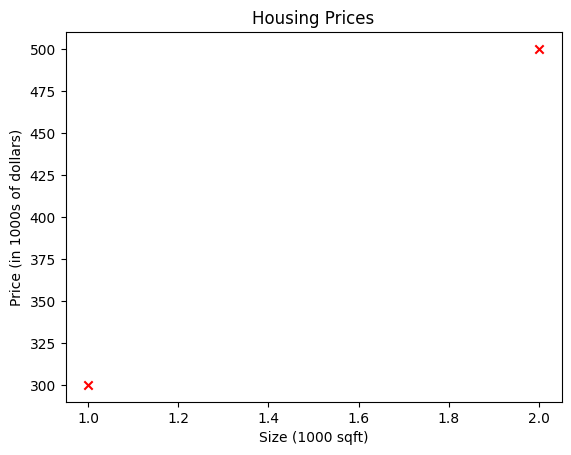

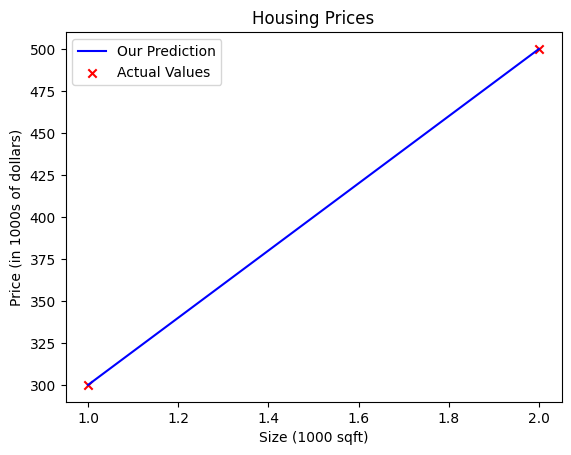

$340 thousand dollars
The compute_cost function has been defined.
The compute_gradient function has been defined.
The gradient_descent function has been defined.
Iteration    0: Cost 7.93e+04, dj_dw: -6.500e+02, dj_db: -4.000e+02, w: 6.500e+00, b: 4.000e+00
Iteration 1000: Cost 3.41e+00, dj_dw: -3.712e-01, dj_db: 6.007e-01, w: 1.949e+02, b: 1.082e+02
Iteration 2000: Cost 7.93e-01, dj_dw: -1.789e-01, dj_db: 2.895e-01, w: 1.975e+02, b: 1.040e+02
Iteration 3000: Cost 1.84e-01, dj_dw: -8.625e-02, dj_db: 1.396e-01, w: 1.988e+02, b: 1.019e+02
Iteration 4000: Cost 4.28e-02, dj_dw: -4.158e-02, dj_db: 6.727e-02, w: 1.994e+02, b: 1.009e+02
Iteration 5000: Cost 9.95e-03, dj_dw: -2.004e-02, dj_db: 3.243e-02, w: 1.997e+02, b: 1.004e+02
Iteration 6000: Cost 2.31e-03, dj_dw: -9.660e-03, dj_db: 1.563e-02, w: 1.999e+02, b: 1.002e+02
Iteration 7000: Cost 5.37e-04, dj_dw: -4.657e-03, dj_db: 7.535e-03, w: 1.999e+02, b: 1.001e+02
Iteration 8000: Cost 1.25e-04, dj_dw: -2.245e-03, dj_db: 3.632e-03, w: 2.000e

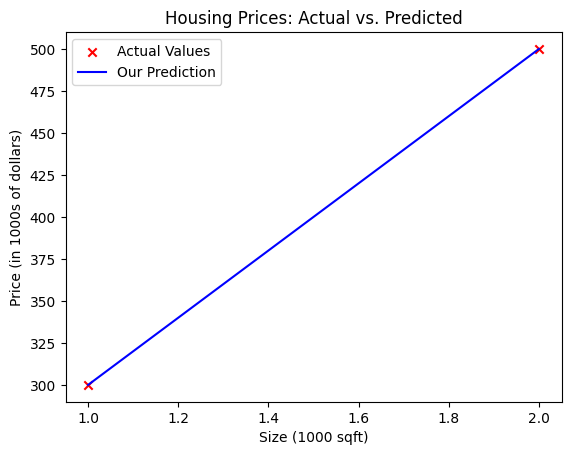

In [95]:
# EXPERIMENT 3
# A) To implement the linear regression model with one variable
#    for housing price prediction
# B) To automate the process of optimizing w and b using gradient descent


import numpy as np
import matplotlib.pyplot as plt


# Training data
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])

print(f"x_train = {x_train}")
print(f"y_train = {y_train}")
print(f"x_train.shape: {x_train.shape}")

m = x_train.shape[0]
print(f"Number of training examples is: {m}")


# Display one training example
i = 1
x_i = x_train[i]
y_i = y_train[i]

print(f"(x^({i}), y^({i})) = ({x_i}, {y_i})")


# Plot the training data
plt.scatter(x_train, y_train, marker='x', c='r')
plt.title("Housing Prices")
plt.ylabel("Price (in 1000s of dollars)")
plt.xlabel("Size (1000 sqft)")
plt.show()


# Initial values of w and b
w = 200
b = 100


# Linear regression model
def compute_model_output(x, w, b):
    """
    Computes the prediction of a linear model.
    """
    m = x.shape[0]
    f_wb = np.zeros(m)

    for i in range(m):
        f_wb[i] = w * x[i] + b

    return f_wb


# Initial model predictions
tmp_f_wb = compute_model_output(x_train, w, b)

plt.plot(x_train, tmp_f_wb, c='b', label='Our Prediction')
plt.scatter(x_train, y_train, marker='x', c='r', label='Actual Values')

plt.title("Housing Prices")
plt.ylabel("Price (in 1000s of dollars)")
plt.xlabel("Size (1000 sqft)")
plt.legend()
plt.show()


# Prediction for a 1200 sqft house
x_i = 1.2
cost_1200sqft = w * x_i + b

print(f"${cost_1200sqft:.0f} thousand dollars")


# Cost function
def compute_cost(x, y, w, b):
    """
    Computes the cost function for linear regression.
    """
    m = x.shape[0]
    total_cost = 0

    for i in range(m):
        f_wb_i = w * x[i] + b
        total_cost += (f_wb_i - y[i]) ** 2

    cost = total_cost / (2 * m)

    return cost


print("The compute_cost function has been defined.")


# Gradient computation
def compute_gradient(x, y, w, b):
    """
    Computes the gradient for linear regression.
    """
    m = x.shape[0]

    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        err = f_wb - y[i]

        dj_dw += err * x[i]
        dj_db += err

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db


print("The compute_gradient function has been defined.")


# Gradient Descent
def gradient_descent(x, y, w_in, b_in, alpha, num_iters):
    """
    Performs batch gradient descent to learn w and b.
    """

    J_history = []
    p_history = []

    b = b_in
    w = w_in

    for i in range(num_iters):

        dj_dw, dj_db = compute_gradient(x, y, w, b)

        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        J_history.append(compute_cost(x, y, w, b))
        p_history.append([w, b])

        if i % (num_iters // 10) == 0:
            print(
                f"Iteration {i:4d}: "
                f"Cost {J_history[-1]:.2e}, "
                f"dj_dw: {dj_dw:.3e}, "
                f"dj_db: {dj_db:.3e}, "
                f"w: {w:.3e}, "
                f"b: {b:.3e}"
            )

    return w, b, J_history, p_history


print("The gradient_descent function has been defined.")


# Initialize parameters
w_init = 0
b_init = 0
iterations = 10000
alpha = 0.01


# Run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(
    x_train,
    y_train,
    w_init,
    b_init,
    alpha,
    iterations
)

print(f"w, b found by gradient descent: ({w_final:.4f}, {b_final:.4f})")


# Final predictions using optimized w and b
f_wb = compute_model_output(x_train, w_final, b_final)

print(f"Predictions with optimal w and b: {f_wb}")


# Plot final linear fit
plt.scatter(
    x_train,
    y_train,
    marker='x',
    c='r',
    label='Actual Values'
)

plt.plot(
    x_train,
    f_wb,
    c='b',
    label='Our Prediction'
)

plt.title("Housing Prices: Actual vs. Predicted")
plt.ylabel("Price (in 1000s of dollars)")
plt.xlabel("Size (1000 sqft)")
plt.legend()
plt.show()